<a href="https://colab.research.google.com/github/sunidhiheroor/AIML-project/blob/main/ml_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== DATASET =====
   Age  Sex  ChestPainType  RestingBP  Cholesterol  MaxHeartRate  Oldpeak  \
0   67    1              1        136          189            80      2.9   
1   57    1              2        114          213           199      4.6   
2   43    1              3        155          299           188      4.1   
3   71    0              0         99          209            89      2.7   
4   36    1              0        145          213            74      1.6   

   Output  
0       0  
1       1  
2       1  
3       0  
4       0  


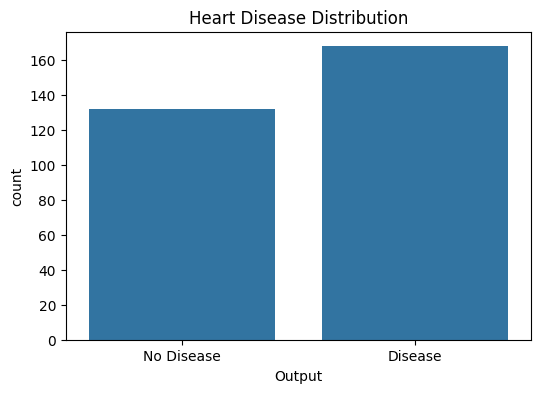

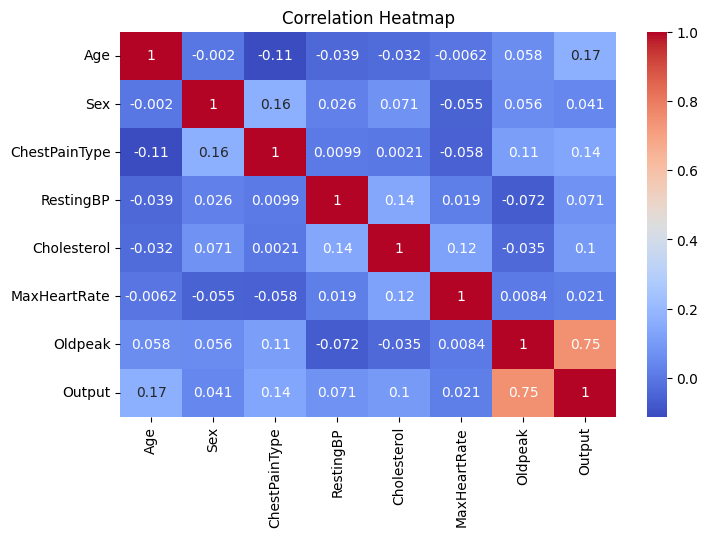

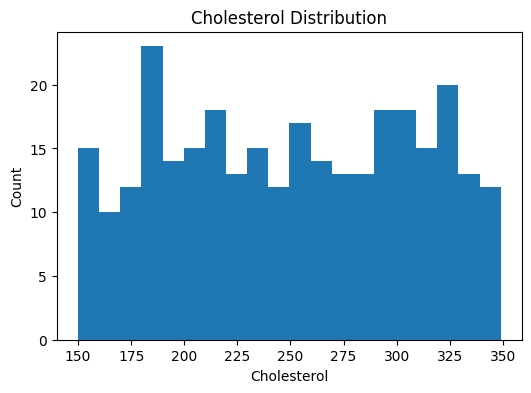

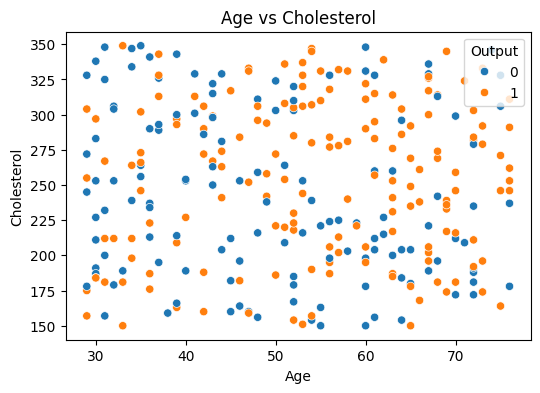


Model Accuracy: 96.66666666666667 %
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d715f2db1a134f0a40.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ==========================================
# HEART DISEASE PREDICTION SYSTEM
# ==========================================

# Install Gradio
!pip install gradio -q

# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import gradio as gr

# ==========================================
# CREATE DATASET
# ==========================================

np.random.seed(42)

data_size = 300

age = np.random.randint(29, 77, data_size)
sex = np.random.randint(0, 2, data_size)
cp = np.random.randint(0, 4, data_size)
trtbps = np.random.randint(90, 180, data_size)
chol = np.random.randint(150, 350, data_size)
thalachh = np.random.randint(70, 202, data_size)
oldpeak = np.round(np.random.uniform(0, 6, data_size), 1)

output = []

# Heart Disease Logic
for i in range(data_size):

    if chol[i] > 240 and trtbps[i] > 140 and age[i] > 50:
        output.append(1)

    elif oldpeak[i] > 3:
        output.append(1)

    else:
        output.append(0)

# Create DataFrame

df = pd.DataFrame({
    'Age': age,
    'Sex': sex,
    'ChestPainType': cp,
    'RestingBP': trtbps,
    'Cholesterol': chol,
    'MaxHeartRate': thalachh,
    'Oldpeak': oldpeak,
    'Output': output
})

# Display Dataset
print("\n===== DATASET =====")
print(df.head())

# ==========================================
# VISUALIZATION
# ==========================================

# Heart Disease Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x='Output', data=df)
plt.title("Heart Disease Distribution")
plt.xticks([0,1], ['No Disease', 'Disease'])
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Cholesterol Distribution
plt.figure(figsize=(6,4))
plt.hist(df['Cholesterol'], bins=20)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Count")
plt.show()

# Age vs Cholesterol
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='Age',
    y='Cholesterol',
    hue='Output',
    data=df
)

plt.title("Age vs Cholesterol")
plt.show()

# ==========================================
# MACHINE LEARNING MODEL
# ==========================================

X = df.drop('Output', axis=1)
y = df['Output']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest Model
model = RandomForestClassifier()

# Train Model
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, pred)

print("\nModel Accuracy:", accuracy * 100, "%")

# ==========================================
# PREDICTION FUNCTION
# ==========================================

def predict_heart_disease(age, sex, cp, bp, chol, hr, oldpeak):

    # Convert input into DataFrame
    input_data = pd.DataFrame([[
        age,
        sex,
        cp,
        bp,
        chol,
        hr,
        oldpeak
    ]],
    columns=[
        'Age',
        'Sex',
        'ChestPainType',
        'RestingBP',
        'Cholesterol',
        'MaxHeartRate',
        'Oldpeak'
    ])

    # Prediction
    prediction = model.predict(input_data)

    # Result
    if prediction[0] == 1:
        result = "High Risk of Heart Disease"
    else:
        result = "Low Risk of Heart Disease"

    # ==========================================
    # DASHBOARD CHART
    # ==========================================

    features = [
        'BloodPressure',
        'Cholesterol',
        'HeartRate',
        'OldPeak'
    ]

    values = [
        bp,
        chol,
        hr,
        oldpeak
    ]

    plt.figure(figsize=(7,4))

    bars = plt.bar(features, values)

    plt.title("Patient Health Dashboard")
    plt.ylabel("Values")

    # Show Values on Bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            yval + 1,
            round(yval,1),
            ha='center'
        )

    plt.show()

    return result

# ==========================================
# FRONTEND USING GRADIO
# ==========================================

interface = gr.Interface(
    fn=predict_heart_disease,

    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="Sex (0=Female, 1=Male)"),
        gr.Number(label="Chest Pain Type (0-3)"),
        gr.Number(label="Resting Blood Pressure"),
        gr.Number(label="Cholesterol"),
        gr.Number(label="Maximum Heart Rate"),
        gr.Number(label="Old Peak")
    ],

    outputs=gr.Textbox(label="Prediction Result"),

    title="Heart Disease Prediction System",

    description="Enter patient health details to predict heart disease risk"
)

# Launch Application
interface.launch()